In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Medicaid project SQL reconstruction\reconciliation_clean_REAL.csv")
df.head()

,meg,budget_enrollment,actual_enrollment,enrollment_variance,enrollment_variance_pct,budget_pmpm,actual_pmpm,pmpm_variance,pmpm_variance_pct,budget_ann_cost,actual_ann_cost,cost_impact
0,ABD Adult,6475,6117,-358,-0.0553,764.19,832.45,68.26,0.0893,5.937756e+07,61105159.8,1727596.80
1,ABD Dual,17649,18307,658,0.0373,257.64,233.05,-24.59,-0.0954,5.456506e+07,51197356.2,-3367704.12
2,General Adult,10049,16159,6110,0.6080,502.44,362.05,-140.39,-0.2794,6.058823e+07,70204391.4,9616156.68
3,New Adult Childless,35802,47805,12003,0.3353,470.11,441.97,-28.14,-0.0599,2.019705e+08,253540510.2,51569971.56
4,New Adult w/Child,22258,25109,2851,0.1281,404.75,437.20,32.45,0.0802,1.081071e+08,131731857.6,23624751.60


In [5]:
df['cost_impact_M'] = df['cost_impact'] / 1e6
df_sorted = df.sort_values('cost_impact_M', ascending=False)
df_sorted[['meg', 'cost_impact_M']]

,meg,cost_impact_M
3,New Adult Childless,51.569972
8,General Child,26.769284
4,New Adult w/Child,23.624752
2,General Adult,9.616157
0,ABD Adult,1.727597
10,CHIP,1.236710
11,Pharmacy Only,0.938957
9,Underinsured Child,0.071998
6,Vermont Cost Sharing,-0.145869
5,Vermont Premium Assist.,-1.090944


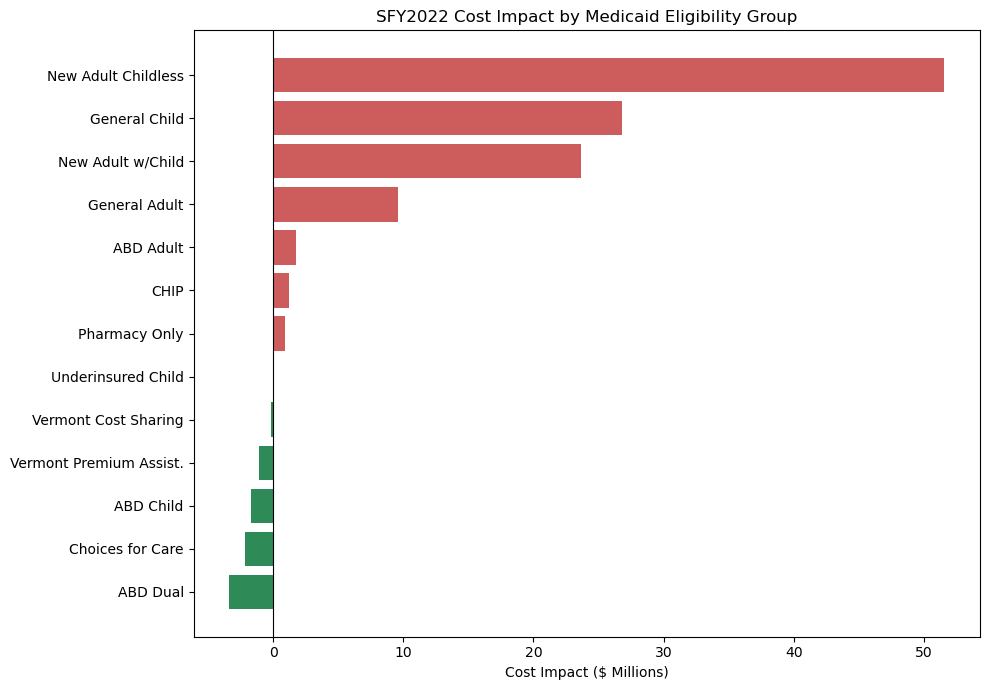

In [11]:
colors = ['indianred' if x > 0 else 'seagreen' for x in df_sorted['cost_impact_M']]

fig, ax = plt.subplots(figsize=(10,7))
ax.barh(df_sorted['meg'], df_sorted['cost_impact_M'], color=colors)
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Cost Impact ($ Millions)')
ax.set_title('SFY2022 Cost Impact by Medicaid Eligibility Group')
plt.tight_layout()
plt.savefig('cost_impact_by_meg.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
df['enrollment_variance_pct'] = (df['enrollment_variance'] / df['budget_enrollment']) * 100
df['pmpm_variance_pct'] = (df['pmpm_variance'] / df['budget_pmpm']) * 100
df[['meg', 'enrollment_variance_pct', 'pmpm_variance_pct']]

,meg,enrollment_variance_pct,pmpm_variance_pct
0,ABD Adult,-5.528958,8.932334
1,ABD Dual,3.728257,-9.544325
2,General Adult,60.802070,-27.941645
3,New Adult Childless,33.526060,-5.985833
4,New Adult w/Child,12.808878,8.017295
5,Vermont Premium Assist.,-21.748133,2.963215
6,Vermont Cost Sharing,-6.025958,-7.314560
7,ABD Child,-3.701380,-4.884786
8,General Child,3.767537,12.446524
9,Underinsured Child,16.226415,0.322628


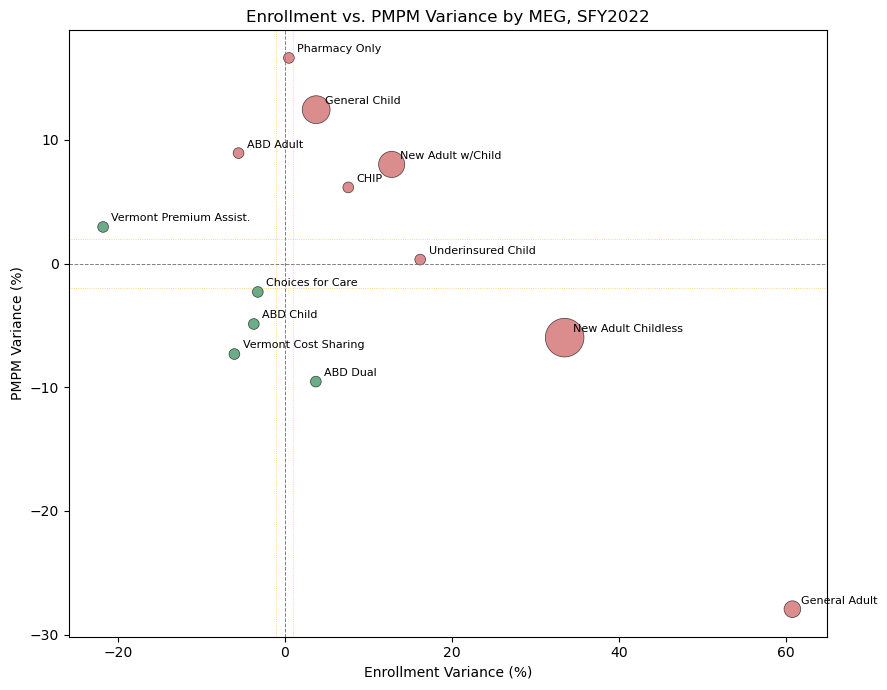

In [22]:
colors2 = ['indianred' if c > 0 else 'seagreen' for c in df ['cost_impact_M']]
sizes = [min(max(abs(c) * 15, 60), 800) for c in df['cost_impact_M']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter (df['enrollment_variance_pct'], df['pmpm_variance_pct'], s=sizes, color=colors2, alpha=0.7, edgecolors='black', linewidth=0.5)

for i, row in df.iterrows():
    ax.annotate (row['meg'], (row['enrollment_variance_pct'], row['pmpm_variance_pct']), textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axhline(2, color='orange', linewidth=0.6, linestyle=':', alpha=0.6)
ax.axhline(-2, color='orange', linewidth=0.6, linestyle=':', alpha=0.6)
ax.axvline(1, color='orange', linewidth=0.6, linestyle=':', alpha=0.6)
ax.axvline(-1, color='orange', linewidth=0.6, linestyle=':', alpha=0.6)
ax.set_xlabel('Enrollment Variance (%)')
ax.set_ylabel('PMPM Variance (%)')
ax.set_title('Enrollment vs. PMPM Variance by MEG, SFY2022')
plt.tight_layout()
plt.savefig('enroll_var_v_pmpm_var_by_meg.png', dpi=150, bbox_inches='tight')
plt.show()
